# Implementação e Análise de uma Máquina de Turing para a Linguagem dos Grafos Bipartidos

# 1. INTRODUÇÃO

## Linguagem Escolhida

Neste trabalho será estudada a Linguagem dos Grafos Bipartidos (LGB).

A linguagem é definida como:


```
LGB = { <G> | G é um grafo bipartido }
```

Um grafo é bipartido quando seus vértices podem ser divididos em dois conjuntos disjuntos de forma que nenhuma aresta conecte vértices pertencentes ao mesmo conjunto.

## Motivação

O problema de verificação de bipartição é um problema clássico da Teoria dos Grafos e da Ciência da Computação.

Ele possui aplicações em problemas de alocação, escalonamento, redes de comunicação e modelagem de relacionamentos.

Neste trabalho será construída uma Máquina de Turing que decide se um grafo pertence ou não à linguagem LGB.

# 2. DEFINIÇÃO FORMAL DA MT

## Codificação da Entrada

Um grafo $G=(V,E)$ é representado na fita por uma palavra da forma:

```text
n#u1,v1;u2,v2;...;um,vm
```

onde:

* $n$ representa a quantidade de vértices do grafo;
* cada par $(u_i,v_i)$ representa uma aresta;
* o símbolo `#` separa o número de vértices da lista de arestas;
* o símbolo `;` separa as arestas;
* o símbolo `,` separa os dois extremos de cada aresta.

Exemplo:

```text
4#1,2;2,3;3,4
```

representa:

```text
V = {1,2,3,4}
E = {(1,2),(2,3),(3,4)}
```

Esse formato é exatamente o que a função `parse_graph` espera ao ler a fita.

---

## O Que a Máquina Guarda

Na implementação deste trabalho, a Máquina de Turing usa a fita para guardar duas coisas:

* a entrada original do grafo;
* uma área de trabalho com as cores dos vértices.

A área de trabalho é montada depois da leitura inicial, com uma separação visual do tipo:

```text
entrada | C:1U;2U;3U;4U; ...
```

Cada célula da área de trabalho corresponde a um vértice:

* `U` significa "ainda não colorido";
* `R` e `G` são as duas cores possíveis;
* `r` e `g` indicam vértices já processados.

Importante: o estado da MT não fica nessa área da fita. O estado fica no controle finito da máquina, enquanto a fita guarda apenas símbolos.

---

## Linguagem

A linguagem estudada neste trabalho é:

$$
LGB={\langle G\rangle \mid G \text{ é um grafo bipartido}}
$$

Ou seja, a linguagem contém todas as codificações de grafos bipartidos.

---

## Estratégia de Decisão

A máquina decide se o grafo é bipartido tentando colorir os vértices com duas cores sem criar conflito entre vértices adjacentes.

O funcionamento real da implementação é este:

1. Ler a codificação do grafo que está escrita na fita.
2. Separar a parte da entrada da área de trabalho.
3. Criar, na própria fita, uma célula de cor para cada vértice.
4. Procurar um vértice ainda não processado.
5. Se o vértice estiver sem cor, atribuir a cor `R`.
6. Fazer a cabeça de leitura/escrita andar até a célula do vértice vizinho consultado.
7. Se o vizinho estiver sem cor, escrever a cor oposta.
8. Se o vizinho já tiver a mesma cor do vértice ativo, rejeitar a entrada.
9. Marcar o vértice atual como processado e seguir para o próximo.
10. Caso todo o grafo seja processado sem conflitos, aceitar a entrada.


---

## Definição Formal

A Máquina de Turing é definida pela 7-upla:

$$
M=(Q,\Sigma,\Gamma,\delta,q_0,\square,F)
$$

---

### Conjunto de Estados (Q)

$$
Q=
{
q_0,
q_{SelectVertex},
q_{ScanEdges},
q_{Accept},
q_{Reject}
}
$$

---

### Papel de Cada Estado

| Estado | Papel na implementação |
| --- | --- |
| $q_0$ | Lê a entrada, interpreta o grafo e prepara a área de trabalho |
| $q_{SelectVertex}$ | Procura o próximo vértice ainda não processado |
| $q_{ScanEdges}$ | Varre as arestas e propaga ou valida as cores |
| $q_{Accept}$ | Estado final de aceitação |
| $q_{Reject}$ | Estado final de rejeição |

---

### Alfabeto de Entrada ($\Sigma$)

$\Sigma$=
{
0,1,2,3,4,5,6,7,8,9,#, ;, ,}



Esses símbolos são suficientes para representar a entrada do grafo.

---

### Alfabeto da Fita ($\Gamma$)

$$
\Gamma=
\Sigma
\cup
{
R,G,r,g,U,|,C,:
\square
}
$$

onde:

| Símbolo | Significado |
| --- | --- |
| $R$ | vértice colorido com vermelho |
| $G$ | vértice colorido com verde |
| $r$ | vértice vermelho já processado |
| $g$ | vértice verde já processado |
| $U$ | vértice ainda sem cor |
| \|  | separador entre entrada e área de trabalho |
| $C$ e $:$ | marcadores da área auxiliar |
| $\square$ | símbolo branco da fita |

---

### Estado Inicial

$$
q_0
$$

---

### Símbolo Branco

$$
\square
$$

---

### Conjunto de Estados Finais

$$
F={q_{Accept}}
$$

O estado $q_{Reject}$ também é terminal, mas leva à rejeição.

---

## Função de Transição

Na implementação, a função de transição não aparece como uma tabela matemática explícita. Ela é simulada pelo método `step()` e pelos auxiliares da classe `TuringMachine`.

Como o código é procedural e depende de variáveis internas como `vertex_cursor`, `edge_index`, `active_vertex` e `active_color`, as transições precisam ser descritas de forma equivalente à execução real da máquina.

### Observação sobre a Natureza das Transições

> **Cada linha da tabela abaixo representa uma macro-transição**, ou seja, uma chamada completa ao método `step()`. Isso difere de uma transição formal de MT, que lê exatamente um símbolo e faz exatamente um movimento de uma célula.
>
> Na prática, dentro de uma única macro-transição, a cabeça pode percorrer **dezenas ou centenas de células** para a esquerda ou direita. Isso ocorre porque o método `_set_head(target)` executa `move_head("R")` ou `move_head("L")` repetidamente, célula por célula, até alcançar a posição da célula de cor do vértice desejado. Para um grafo com $n$ vértices, a área de trabalho ocupa aproximadamente $3n$ células após a entrada, de forma que cada consulta de cor pode custar $O(n)$ movimentos reais de cabeça.
>
> Na tabela, a notação **`L/R*`** indica que a cabeça realiza múltiplos movimentos (para esquerda ou direita, conforme a posição relativa). O símbolo **`S`** é usado apenas nos casos em que a cabeça genuinamente não se move durante aquela macro-transição.

### Tabela de Macro-Transições

| Estado Atual | Condição | Próximo Estado | Efeito na Fita | Direção |
| ------------ | --------- | -------------- | -------------- | ------- |
| `q0` | Entrada malformada (`parse_graph` retorna `None`) | `qReject` | — | `S`¹ |
| `q0` | Vértice fora do intervalo (`build_graph` retorna `None`) | `qReject` | — | `S`¹ |
| `q0` | Entrada válida | `qSelectVertex` | Fita estendida à direita com `\|C:1U;2U;...;nU;\|` | `S`¹ |
| `qSelectVertex` | Cor do vértice = `U` | `qScanEdges` | Escreve `R` na célula do vértice | `L/R*`² |
| `qSelectVertex` | Cor do vértice = `R` | `qScanEdges` | Não escreve | `L/R*`² |
| `qSelectVertex` | Cor do vértice = `G` | `qScanEdges` | Não escreve | `L/R*`² |
| `qSelectVertex` | Cor do vértice = `r` ou `g` (já processado) | `qSelectVertex` | Não escreve; avança para o próximo vértice na mesma macro-transição | `L/R*`² |
| `qSelectVertex` | Todos os vértices foram processados | `qAccept` | — | `L/R*`² |
| `qScanEdges` | Aresta não incidente ao vértice ativo | `qScanEdges` | Não escreve | `S`³ |
| `qScanEdges` | Vizinho com `U`, cor ativa = `R` | `qScanEdges` | Escreve `G` na célula do vizinho | `L/R*`² |
| `qScanEdges` | Vizinho com `U`, cor ativa = `G` | `qScanEdges` | Escreve `R` na célula do vizinho | `L/R*`² |
| `qScanEdges` | Vizinho com `R` ou `r`, cor ativa = `R` (conflito) | `qReject` | — | `L/R*`² |
| `qScanEdges` | Vizinho com `G` ou `g`, cor ativa = `G` (conflito) | `qReject` | — | `L/R*`² |
| `qScanEdges` | Vizinho com `G` ou `g`, cor ativa = `R` (sem conflito) | `qScanEdges` | Não escreve | `L/R*`² |
| `qScanEdges` | Vizinho com `R` ou `r`, cor ativa = `G` (sem conflito) | `qScanEdges` | Não escreve | `L/R*`² |
| `qScanEdges` | Todas as arestas examinadas | `qSelectVertex` | Escreve `r` ou `g` na célula do vértice ativo | `L/R*`² |
| `qAccept` ou `qReject` | (estado terminal) | — | — | `S` |

**Notas:**

¹ **`q0` — Direção `S`:** A cabeça não se move durante a macro-transição de `q0`. A fita é lida via `"".join(self.tape)` diretamente em Python, sem chamar `move_head`. A área de trabalho é criada com `tape.append()`, que estende a lista sem alterar `self.head`. A cabeça permanece na posição 0.

² **`L/R*` — Múltiplos movimentos reais de cabeça:** O método `_set_head(target)` é chamado sempre que a máquina precisa ler ou escrever a cor de um vértice. Ele executa `move_head("R")` ou `move_head("L")` em laço até atingir `target`. Cada chamada a `move_head` é um passo real de cabeça na MT. O custo acumulado desses deslocamentos — proporcional à distância entre a posição atual e a célula alvo — é a principal razão pela qual a complexidade observada ultrapassa $O(V \cdot E)$ e se aproxima de $O(V \cdot E \cdot n)$ na prática.

³ **`qScanEdges` — Direção `S` para arestas não incidentes:** Quando a aresta não envolve o vértice ativo, o código executa `return True` imediatamente sem chamar `_set_head`. A cabeça genuinamente não se move nesse caso específico.

### Leitura das Macro-Transições

* `q0` lê toda a entrada de uma vez, valida o grafo e cria a área de trabalho na fita.
* `qSelectVertex` varre as células de cor dos vértices, movendo a cabeça, até encontrar um não processado. Todos os vértices processados (`r`/`g`) são pulados dentro da mesma macro-transição.
* `qScanEdges` examina cada aresta. Para arestas incidentes ao vértice ativo, move a cabeça até a célula do vizinho para ler ou escrever sua cor. Para arestas não incidentes, não move a cabeça.
* Quando encontra vizinho sem cor (`U`), escreve a cor oposta na fita.
* Quando detecta conflito de cor, vai para `qReject` sem mais movimentos.
* Ao terminar todas as arestas, marca o vértice ativo como processado na fita e volta a `qSelectVertex`.

## Ideia Central

A parte mais importante é entender a divisão entre:

* **controle finito**: guarda o estado atual;
* **cabeça de leitura/escrita**: anda pela fita, célula por célula, e pode percorrer dezenas de posições por macro-transição;
* **fita**: guarda entrada, separador e área de trabalho.

Ou seja, a "lógica da MT" está no controle finito, enquanto a fita só registra informações que a cabeça precisa ler e atualizar. O custo de movimentação da cabeça é real e contabilizado no contador de passos (`self.steps`), pois cada chamada a `move_head` incrementa indiretamente o número de operações realizadas pela simulação.


# 3. IMPLEMENTAÇÃO

Nesta seção é apresentada a implementação da Máquina de Turing em Python.

O código foi organizado para refletir três ideias principais:

* leitura da entrada codificada na fita;
* criação de uma área de trabalho para as cores dos vértices;
* simulação passo a passo do comportamento da MT por meio de estados e movimentação da cabeça.


### Funções Auxiliares

As funções auxiliares fazem a ponte entre a entrada textual e a estrutura usada pela simulação da Máquina de Turing.

`parse_graph` lê a palavra escrita na fita no formato `n#u,v;u,v;...` e separa:

* `n`, que é a quantidade de vértices;
* `edges`, que é a lista de arestas.

`build_graph` valida se os vértices informados existem e monta uma lista de adjacência.

Essas funções não decidem se o grafo é bipartido. Elas apenas garantem que a entrada possa ser interpretada corretamente antes da simulação continuar.


In [ ]:
from typing import Dict, List, Optional, Tuple
def parse_graph(tape_string: str):
    """
    Interpreta a entrada codificada na fita no formato:

        n#u1,v1;u2,v2;...;um,vm

    Nesta funcao, a fita ainda contem apenas a entrada bruta.
    O objetivo e separar:
    - n: quantidade de vertices;
    - edges: lista de arestas.

    Se a codificacao estiver invalida, retorna None.
    """

    try:
        # Separa a quantidade de vertices da lista de arestas.
        parts = tape_string.split("#")
        if len(parts) != 2:
            return None

        # A parte da esquerda precisa ser um numero inteiro.
        n = int(parts[0])

        edges = []

        # Grafo sem arestas tambem e valido.
        if parts[1] == "":
            return n, edges

        # Cada aresta e escrita como "u,v" e separada por ";".
        for edge in parts[1].split(";"):
            vertices = edge.split(",")
            if len(vertices) != 2:
                return None

            # Converte os dois extremos da aresta para inteiros.
            u = int(vertices[0])
            v = int(vertices[1])
            edges.append((u, v))

        return n, edges
    except Exception:
        return None



In [ ]:
def build_graph(n: int, edges: List[Tuple[int, int]]):
    """
    Constroi uma lista de adjacencia apenas para validar a entrada.

    A MT nao usa essa estrutura como memoria principal da decisao.
    Ela serve para conferir se os vertices informados realmente existem.
    """

    # O numero de vertices precisa ser positivo.
    if n <= 0:
        return None

    # Cria uma lista vazia de vizinhos para cada vertice.
    graph = {vertex: [] for vertex in range(1, n + 1)}

    for u, v in edges:
        # Cada extremidade precisa estar dentro do intervalo valido.
        if u < 1 or u > n:
            return None
        if v < 1 or v > n:
            return None

        # O grafo e nao direcionado, entao a aresta entra nos dois lados.
        graph[u].append(v)
        graph[v].append(u)

    return graph


## Classe TuringMachine

A classe `TuringMachine` implementa a simulação da MT de forma operacional.

Os componentes mais importantes são:

* `self.state`: guarda o estado atual da MT;
* `self.head`: representa a cabeça de leitura/escrita;
* `self.tape`: representa a fita;
* `self.color_positions`: mapeia cada vértice para a célula da fita onde sua cor fica armazenada;
* `self.vertex_cursor` e `self.edge_index`: controlam a varredura dos vértices e das arestas;
* `self.active_vertex` e `self.active_color`: guardam qual vértice está sendo processado na rodada atual.

A ideia principal é:

1. ler a entrada;
2. criar uma área auxiliar na fita para as cores;
3. escolher um vértice;
4. mover a cabeça até as células necessárias;
5. escrever ou conferir cores;
6. aceitar ou rejeitar.

É feito um ciclo de seleção de vértices e varredura das arestas, sempre guiado pelo estado atual da máquina.

### Resumo dos métodos

| Método | Função na MT |
| --- | --- |
| `step()` | executa uma transição de acordo com o estado atual |
| `read_symbol()` | lê o símbolo sob a cabeça |
| `write_symbol()` | escreve na célula atual da fita |
| `move_head()` | move a cabeça uma célula por vez |
| `_set_head()` | posiciona a cabeça na célula desejada |
| `_read_vertex_color()` | consulta a cor de um vértice na área de trabalho |
| `_write_vertex_color()` | atualiza a cor de um vértice |


In [ ]:
from typing import Dict, List, Optional, Tuple

class TuringMachine:
    """
    Simulacao de uma Maquina de Turing para decidir se um grafo e bipartido.

    A ideia e seguir o modelo de MT:
    - a entrada fica escrita na fita;
    - a cabeca de leitura/escrita aponta para uma celula de cada vez;
    - o estado atual controla o que a maquina faz;
    - a fita tambem guarda a memoria de trabalho, como as cores dos vertices.

    A MT faz varreduras sucessivas sobre a fita e sobre a tabela
    de cores, movimentando a cabeca passo a passo.
    """

    def __init__(self, tape):
        # Simbolo branco da fita.
        self.blank = "â–¡"

        # A fita e representada por uma lista de simbolos.
        self.tape = list(tape)

        # Se a entrada vier vazia, garante pelo menos uma celula branca.
        if not self.tape:
            self.tape.append(self.blank)

        # Cabeca de leitura/escrita: este e o ponteiro da MT sobre a fita.
        self.head = 0

        # Estado inicial da maquina.
        self.state = "q0"

        # Contador de passos da simulacao.
        self.steps = 0

        # Estruturas auxiliares para interpretar a entrada ja lida.
        self.graph = None
        self.edges = []
        self.vertices = []

        # Mapeia cada vertice para a posicao da sua celula de cor na fita.
        # Assim, a cabeca consegue voltar exatamente ao ponto correto.
        self.color_positions: Dict[int, int] = {}

        # Ponteiro logico para o proximo vertice a ser examinado.
        self.vertex_cursor = 0

        # Vertice ativo no momento.
        self.active_vertex: Optional[int] = None

        # Cor atual do vertice ativo.
        self.active_color: Optional[str] = None

        # Indice da aresta sendo lida na varredura atual.
        self.edge_index = 0

    # --------------------------------------------------
    # Operacoes sobre a fita
    # --------------------------------------------------

    def read_symbol(self):
        """
        Le o simbolo que esta na celula apontada pela cabeca.

        Se a cabeca sair dos limites, a fita e expandida com simbolos brancos.
        Isso imita a fita infinita de uma Maquina de Turing.
        """

        # Se a cabeca andar para a esquerda alem do inicio, criamos espaco.
        while self.head < 0:
            self.tape.insert(0, self.blank)
            self.head += 1

        # Se a cabeca ultrapassar o fim, estendemos a fita a direita.
        while self.head >= len(self.tape):
            self.tape.append(self.blank)

        return self.tape[self.head]

    def write_symbol(self, symbol):
        """
        Escreve um simbolo na celula apontada pela cabeca.

        Em uma MT, leitura e escrita acontecem no mesmo ponto da fita.
        """

        # Garante que a posicao atual exista antes de escrever.
        while self.head < 0:
            self.tape.insert(0, self.blank)
            self.head += 1

        while self.head >= len(self.tape):
            self.tape.append(self.blank)

        self.tape[self.head] = symbol

    def move_head(self, direction):
        """
        Move a cabeca da MT:
        - R: uma celula para a direita;
        - L: uma celula para a esquerda;
        - S: permanece parada.
        """

        if direction == "R":
            self.head += 1
        elif direction == "L":
            self.head -= 1
        elif direction == "S":
            pass

        # Mantem a fita sempre expansivel.
        if self.head < 0:
            self.tape.insert(0, self.blank)
            self.head = 0
        elif self.head >= len(self.tape):
            self.tape.append(self.blank)

    def _set_head(self, target):
        """
        Posiciona a cabeca em um indice especifico da fita.

        Isto e importante conceitualmente: uma MT nao acessa memoria
        aleatoriamente. Ela precisa mover a cabeca celula por celula.
        """

        while self.head < target:
            self.move_head("R")
        while self.head > target:
            self.move_head("L")

    def _base_color(self, symbol):
        """
        Normaliza a cor lida na fita.

        As letras minusculas indicam vertices ja processados,
        entao convertemos para a cor base correspondente.
        """

        if symbol in {"R", "r"}:
            return "R"
        if symbol in {"G", "g"}:
            return "G"
        return symbol

    def _opposite_color(self, symbol):
        """Retorna a cor oposta da cor recebida."""
        return "G" if symbol == "R" else "R"

    def _color_position(self, vertex):
        """Recupera a posicao da celula de cor do vertice informado."""
        return self.color_positions[vertex]

    def _read_vertex_color(self, vertex):
        """
        Move a cabeca ate a celula do vertice e le sua cor.

        Aqui a fita faz o papel da memoria da MT, e a cabeca e o ponteiro
        que vai ate a posicao correta para consultar o estado do vertice.
        """

        position = self._color_position(vertex)
        self._set_head(position)
        return self.read_symbol()

    def _write_vertex_color(self, vertex, symbol):
        """
        Move a cabeca ate a celula do vertice e escreve a nova cor.

        Esta operacao simula a atualizacao da memoria de trabalho da MT.
        """

        position = self._color_position(vertex)
        self._set_head(position)
        self.write_symbol(symbol)

    def _initialize_work_area(self, n):
        """
        Monta uma area auxiliar na fita para armazenar as cores.

        A estrutura fica assim, de forma conceitual:

        entrada original | C: 1U;2U;3U;... |

        Onde:
        - U = vertice sem cor;
        - R = uma cor;
        - G = a outra cor;
        - r/g = vertice ja processado.
        """

        # Se a entrada ainda nao foi separada da area de trabalho, adiciona um marcador.
        if self.tape and self.tape[-1] != "|":
            self.tape.append("|")

        # Marca o inicio da regiao de trabalho da MT.
        self.tape.extend(list("C:"))
        self.color_positions = {}

        # Cria uma celula de cor para cada vertice.
        for vertex in range(1, n + 1):
            # Mantem o numero do vertice gravado antes da cor.
            for ch in str(vertex):
                self.tape.append(ch)

            # Esta posicao passa a representar a cor do vertice.
            color_pos = len(self.tape)
            self.tape.append("U")
            self.color_positions[vertex] = color_pos

            # Separador visual entre vertices.
            self.tape.append(";")

        # Marca o fim da area auxiliar.
        self.tape.append("|")

    # --------------------------------------------------
    # Uma transicao da MT
    # --------------------------------------------------

    def step(self):
        """
        Executa uma transicao da Maquina de Turing.

        Cada chamada representa uma pequena mudanca de estado,
        com leitura, escrita e movimentacao da cabeca.
        """

        # Cada transicao consome um passo da simulacao.
        self.steps += 1

        # q0: interpreta a entrada e prepara a area de trabalho.
        if self.state == "q0":
            # Lemos a fita inteira como a entrada escrita pelo usuario.
            tape_string = "".join(self.tape).replace(self.blank, "")
            graph_data = parse_graph(tape_string)

            # Entrada invalida leva a rejeicao imediata.
            if graph_data is None:
                self.state = "qReject"
                return False

            n, edges = graph_data
            graph = build_graph(n, edges)

            # Se houver vertices fora do intervalo, a MT rejeita.
            if graph is None:
                self.state = "qReject"
                return False

            # Guarda a estrutura do grafo apenas como apoio da simulacao.
            self.graph = graph
            self.edges = edges
            self.vertices = list(range(1, n + 1))

            # Cria a tabela de cores diretamente na fita.
            self._initialize_work_area(n)

            # Reinicia os ponteiros logicos da simulacao.
            self.vertex_cursor = 0
            self.active_vertex = None
            self.active_color = None
            self.edge_index = 0

            # Proximo estado: procurar um vertice para processar.
            self.state = "qSelectVertex"
            return True

        # qSelectVertex: procura o proximo vertice ainda nao processado.
        if self.state == "qSelectVertex":
            # Varre os vertices na ordem 1..n.
            while self.vertex_cursor < len(self.vertices):
                vertex = self.vertices[self.vertex_cursor]

                # Posiciona a cabeca na celula correspondente ao vertice.
                symbol = self._read_vertex_color(vertex)

                # Se ainda estiver sem cor, a MT escolhe uma cor inicial.
                if symbol == "U":
                    self._write_vertex_color(vertex, "R")
                    symbol = "R"

                # Se o vertice ja tem cor, ele vira o vertice ativo da rodada.
                if symbol in {"R", "G"}:
                    self.active_vertex = vertex
                    self.active_color = symbol
                    self.edge_index = 0
                    self.state = "qScanEdges"
                    return True

                # Caso inesperado, apenas avanca para o proximo.
                self.vertex_cursor += 1

            # Se nenhum vertice restar para processar, a MT aceita.
            self.state = "qAccept"
            return False

        # qScanEdges: varre todas as arestas procurando conflitos.
        if self.state == "qScanEdges":
            # Se todas as arestas ja foram examinadas, finaliza o vertice atual.
            if self.edge_index >= len(self.edges):
                # Marca o vertice como processado usando minuscula.
                if self.active_vertex is not None and self.active_color is not None:
                    self._write_vertex_color(
                        self.active_vertex,
                        self.active_color.lower(),
                    )

                # Limpa o vertice ativo e prepara a proxima rodada.
                self.active_vertex = None
                self.active_color = None
                self.vertex_cursor += 1
                self.state = "qSelectVertex"
                return True

            # Lemos a proxima aresta da lista interpretada.
            u, v = self.edges[self.edge_index]
            self.edge_index += 1

            # Se a aresta nao toca o vertice ativo, ela e ignorada nesta rodada.
            if self.active_vertex not in (u, v):
                return True

            # Identifica o vizinho do vertice ativo nesta aresta.
            neighbor = v if u == self.active_vertex else u

            # A cabeca vai ate a celula do vizinho para consultar sua cor.
            neighbor_symbol = self._read_vertex_color(neighbor)
            neighbor_color = self._base_color(neighbor_symbol)

            # Se o vizinho ainda nao tem cor, grava a cor oposta na fita.
            if neighbor_symbol == "U":
                self._write_vertex_color(
                    neighbor,
                    self._opposite_color(self.active_color),
                )
                return True

            # Se o vizinho ja tem a mesma cor, existe conflito e a MT rejeita.
            if neighbor_color == self.active_color:
                self.state = "qReject"
                return False

            # Sem conflito, continua a varredura da fita.
            return True

        # Estados terminais apenas interrompem a computacao.
        return False

    # --------------------------------------------------
    # Execucao completa
    # --------------------------------------------------

    def execute(self, step_limit=300000):
        """
        Executa a MT ate aceitar, rejeitar ou atingir um limite de passos.

        O limite e uma protecao contra loops causados por erros de entrada
        ou por alguma inconsistencia de implementacao.
        """

        while self.steps < step_limit:
            keep_running = self.step()

            # Se a MT chegou ao estado de aceite, retornamos sucesso.
            if self.state == "qAccept":
                return True, self.steps, "".join(self.tape)

            # Se a MT chegou ao estado de rejeicao, retornamos falha.
            if self.state == "qReject":
                return False, self.steps, "".join(self.tape)

            # Se a transicao indicar parada, encerramos o laço.
            if not keep_running:
                break

        # Se o limite for atingido, tratamos como rejeicao segura.
        return False, self.steps, "".join(self.tape)



# 4. TESTES

- Testes Automatizados
- Sequências de grafos bipartidos e não bipartidos
- Sequências erradas

O algoritmo passou em todos os testes com sucesso

In [ ]:
tests = [
    # (entrada, resultado_esperado)

    # Grafos bipartidos
    ("4#1,2;2,3;3,4", True),
    ("2#1,2", True),
    ("5#1,2;1,4;3,2;3,5", True),
    ("6#1,2;2,3;3,4;4,5;5,6", True),

    # Grafos não bipartidos
    ("3#1,2;2,3;3,1", False),
    ("5#1,2;2,3;3,4;4,5;5,1", False),
    ("7#1,2;2,3;3,1", False),

    # Entradas malformadas
    ("abc", False),
    ("4#1,2;2", False),
    ("4#1,5", False),
]

passed = 0

for i, (entrada, esperado) in enumerate(tests, start=1):

    tm = TuringMachine(entrada)

    aceita, passos, _ = tm.execute()

    status = "OK" if aceita == esperado else "ERRO"

    print(
        f"Teste {i:02d} | "
        f"Entrada: {entrada:<25} | "
        f"Esperado: {esperado} | "
        f"Obtido: {aceita} | "
        f"Passos: {passos} | "
        f"{status}"
    )
    if aceita == esperado:
        passed += 1

print("\nResumo:")
print(f"{passed}/{len(tests)} testes passaram")

Teste 01 | Entrada: 4#1,2;2,3;3,4             | Esperado: True | Obtido: True | Passos: 22 | OK
Teste 02 | Entrada: 2#1,2                     | Esperado: True | Obtido: True | Passos: 8 | OK
Teste 03 | Entrada: 5#1,2;1,4;3,2;3,5         | Esperado: True | Obtido: True | Passos: 32 | OK
Teste 04 | Entrada: 6#1,2;2,3;3,4;4,5;5,6     | Esperado: True | Obtido: True | Passos: 44 | OK
Teste 05 | Entrada: 3#1,2;2,3;3,1             | Esperado: False | Obtido: False | Passos: 9 | OK
Teste 06 | Entrada: 5#1,2;2,3;3,4;4,5;5,1     | Esperado: False | Obtido: False | Passos: 27 | OK
Teste 07 | Entrada: 7#1,2;2,3;3,1             | Esperado: False | Obtido: False | Passos: 9 | OK
Teste 08 | Entrada: abc                       | Esperado: False | Obtido: False | Passos: 1 | OK
Teste 09 | Entrada: 4#1,2;2                   | Esperado: False | Obtido: False | Passos: 1 | OK
Teste 10 | Entrada: 4#1,5                     | Esperado: False | Obtido: False | Passos: 1 | OK

Resumo:
10/10 testes passaram


# 5. ANÁLISE DE COMPLEXIDADE

## Gerador de Instâncias
Gerador de Instâncias da linguagem que varia seus tamanhos e tipos de entradas e realiza 10 execuções por tamanho.

Também calcula a complexidade esperada e a razão da quantidade da Media de Passos Real e a Media de Passos Teórica

In [ ]:
import statistics
import pandas as pd

def gerar_grafo_caminho(n):

    arestas = []

    for i in range(1, n):
        arestas.append(f"{i},{i+1}")

    return f"{n}#" + ";".join(arestas)

def gerar_grafo_ciclo_par(n):

    if n % 2 != 0:
        n += 1

    arestas = []

    for i in range(1, n):
        arestas.append(f"{i},{i+1}")

    arestas.append(f"{n},1")

    return f"{n}#" + ";".join(arestas)

def gerar_grafo_bipartido_completo(n):

    if n % 2 != 0:
        n += 1

    metade = n // 2

    arestas = []

    for u in range(1, metade + 1):

        for v in range(metade + 1, n + 1):

            arestas.append(f"{u},{v}")

    return f"{n}#" + ";".join(arestas)

def complexidade_teorica(tipo, n):

    if tipo == "caminho":

        e = n - 1

    elif tipo == "ciclo":

        e = n

    elif tipo == "completo":

        e = (n // 2) ** 2

    return n * (e + 1)


## Função de medição de complexidade e Tabela com resultado

In [ ]:
geradores = [
    gerar_grafo_caminho,
    gerar_grafo_ciclo_par,
    gerar_grafo_bipartido_completo
]

sizes = [10,20,30,40,50,60,80,100]

results = []

for n in sizes:

    passos_n = []
    teoricos_n = []

    for gerador in geradores:

        entrada = gerador(n)

        tm = TuringMachine(entrada)

        aceita, passos, _ = tm.execute()

        passos_n.append(passos)

        graph_data = parse_graph(entrada)
        _, edges = graph_data

        teoricos_n.append(
            n * (len(edges) + 1)
        )

    results.append({
        "n": n,
        "media_passos": statistics.mean(passos_n),
        "desvio": statistics.stdev(passos_n),
        "media_teorica": statistics.mean(teoricos_n)
    })
df = pd.DataFrame(results)

df["razao"] = (
    df["media_passos"] /
    df["media_teorica"]
)

print(df.round(2))


     n  media_passos     desvio  media_teorica  razao
0   10        168.67      89.63         156.67   1.08
1   20        968.67     929.59         946.67   1.02
2   30       2902.00    3386.19        2870.00   1.01
3   40       6468.67    8325.41        6426.67   1.01
4   50      12168.67   16613.27       12116.67   1.00
5   60      20502.00   29115.79       20440.00   1.00
6   80      47068.67   70228.90       46986.67   1.00
7  100      90168.67  138592.94       90066.67   1.00


## Gráfico de Passos VS Tamanho (com barras de erro)

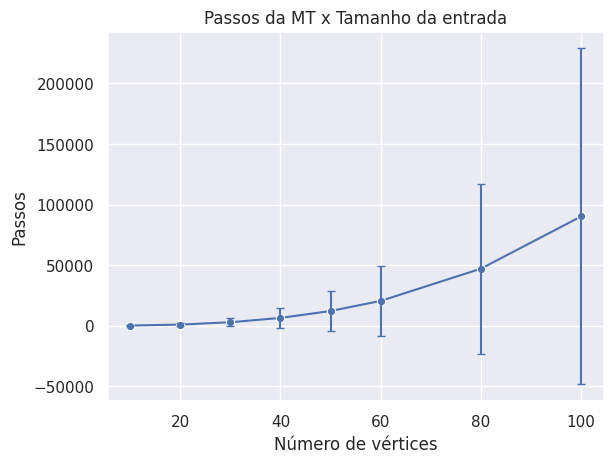

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme()

sns.lineplot(
    data=df,
    x="n",
    y="media_passos",
    marker="o",
    err_style="bars",
    errorbar=None
)

plt.errorbar(
    df["n"],
    df["media_passos"],
    yerr=df["desvio"],
    fmt="none",
    capsize=3
)

plt.xlabel("Número de vértices")
plt.ylabel("Passos")
plt.title("Passos da MT x Tamanho da entrada")
plt.grid(True)

plt.show()

# 6. DISCUSSÃO



## Análise dos Resultados

Os resultados mostram que a quantidade de passos cresce conforme o tamanho do grafo aumenta, mas esse crescimento não depende apenas do número de vértices.

Isso acontece porque a implementação faz duas coisas ao mesmo tempo:

* percorre novamente as arestas para cada vértice ativo;
* move a cabeça na fita para consultar e atualizar as cores.

Por isso, grafos com mais arestas ou com maior necessidade de movimentação da cabeça tendem a exigir mais passos, isso ocorre nos Grafos de Bipartição Completos que são mais densos que Grafos Bipartidos de Caminho e de Ciclo.

## Comparação com Complexidade Teórica

A verificação de bipartição aqui não depende de fila explícita.

Na implementação:

* `qSelectVertex` percorre os vértices;
* `qScanEdges` percorre as arestas para o vértice ativo;
* a cabeça ainda precisa se deslocar até a célula de cada vértice na área de trabalho.

Isso torna o custo dominado por varreduras repetidas e pela movimentação da cabeça. Então, de forma simplificada, a complexidade observada fica na ordem de:

$$
O(V * E)
$$

com custo adicional de movimentação da cabeça na fita. Sendo que em grafos densos essa complexidade pode chegar até O(n³)


## Dificuldades encontradas

- Entender como uma máquina de turing poderia implementar a verificação da linguagem.
- Implementar geradores de grafos além dos grafos de Caminho e de Ciclo, a fim de entender casos extremos do uso já que anteriormente a complexidade parecia mais simples
- Utilizar os steps de forma fiel para que isso pudesse ser estudado nesse tópico


# 7. CONCLUSÃO



## Principais Aprendizados

- O estado da Máquina de Turing fica no controle finito, não na fita.
- A cabeça de leitura/escrita é o elemento que percorre a fita célula por célula.
- A fita pode ser usada como memória de trabalho para guardar informações auxiliares.
- É possível simular a coloração do grafo por meio de varreduras sucessivas.


## Limitações do Estudo

- A implementação é uma simulação em Python, então ela usa estruturas auxiliares como lista de arestas e mapeamento de posições de cor.
- Grafos muito grandes exigem muitos passos, porque a cabeça precisa se mover na fita e as arestas são varridas repetidamente.
